## Lab 4: Generating CDFs

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma

### Question 3

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability , and we want to study the distribution of the survivors.

**1. Flip n = 40 coins, which each come up heads with probability  and tails with complementary probability.**

In [4]:
n = 40
p = 0.5
b = 5000
results = []
heads = np.random.binomial(n=n, p=p)

**2. From the final count of heads, subtract the expected number of heads, n * p.**

In [6]:
expected = n * p
centered = heads - expected

**3. Divide by the standard deviation sqrt( n * p * (1-p) )**

In [7]:
sd = np.sqrt(n * p * (1 - p))
z = centered / sd

**4. Repeat the above process b = 5000 times and plot the ECDF.**

In [8]:
for i in range(b):

    heads = np.random.binomial(n=n, p=p)
    expected = n * p
    sd = np.sqrt(n * p * (1 - p))
    z = (heads - expected) / sd
    results.append(z)

results = np.array(results)

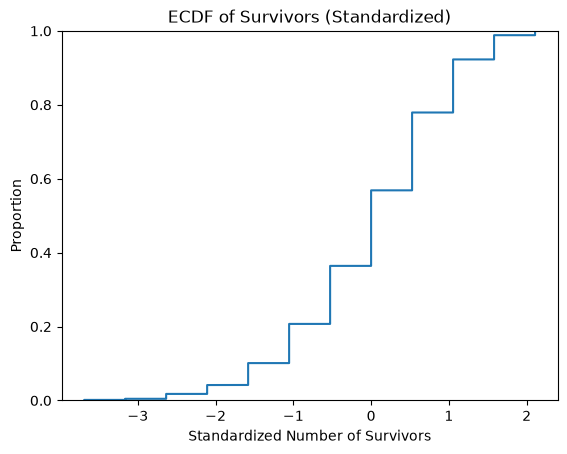

In [43]:
sns.ecdfplot(results)
plt.xlabel("Standardized Number of Survivors")
plt.ylabel("Proportion")
plt.title("ECDF of Survivors (Standardized)")
plt.show()

**5. What distribution does this approach as n increases?**

Because we are standardizing a Binomial random variable (Z), Z should approach 1 as n increases. Therefore, the ECDF should approach the normal CDF distribution.

**6. How do the results change as you adjust p?**

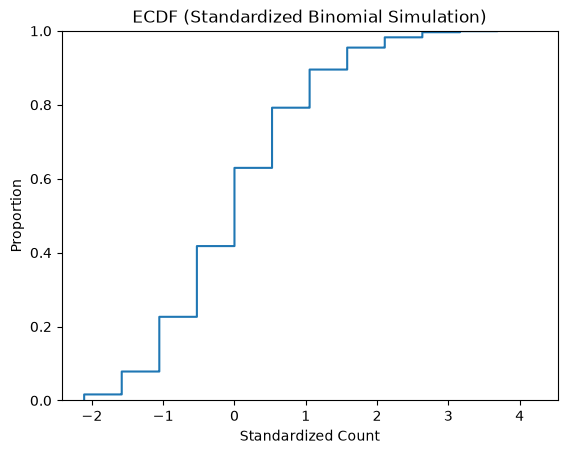

In [ ]:
n = 40
p = 0.1
b = 5000
results = []

for i in range(b):
    heads = np.random.binomial(n=n, p=p)
    z = (heads - n*p) / np.sqrt(n*p*(1-p))
    results.append(z)
results = np.array(results)
sns.ecdfplot(results)
plt.xlabel("Standardized Number of Survivors")
plt.ylabel("Proportion")
plt.title("ECDF of Survivors (Standardized)")
plt.show()

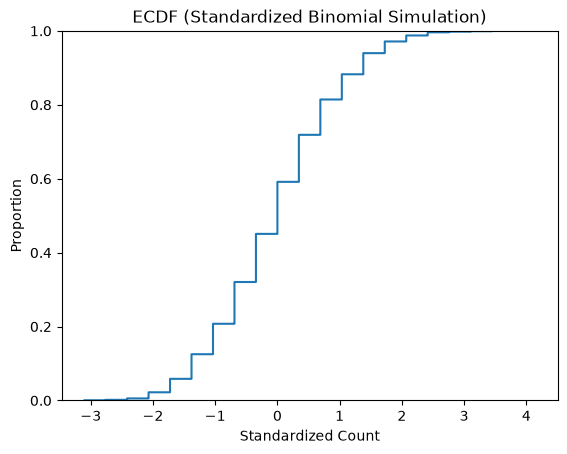

In [ ]:
n = 40
p = 0.3
b = 5000
results = []

for i in range(b):
    heads = np.random.binomial(n=n, p=p)
    z = (heads - n*p) / np.sqrt(n*p*(1-p))
    results.append(z)
results = np.array(results)
sns.ecdfplot(results)
plt.xlabel("Standardized Number of Survivors")
plt.ylabel("Proportion")
plt.title("ECDF of Survivors (Standardized)")
plt.show()

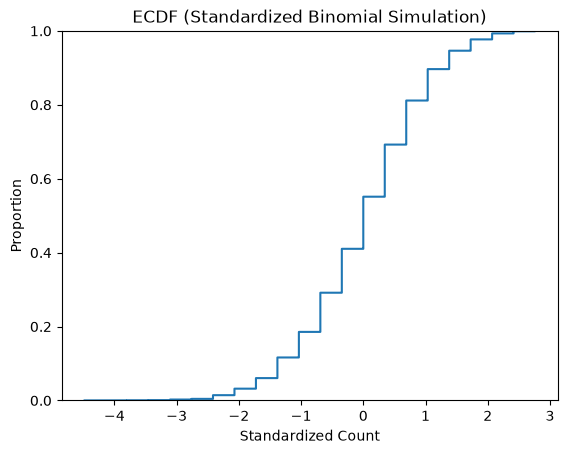

In [ ]:
n = 40
p = 0.7
b = 5000
results = []

for i in range(b):
    heads = np.random.binomial(n=n, p=p)
    z = (heads - n*p) / np.sqrt(n*p*(1-p))
    results.append(z)
results = np.array(results)
sns.ecdfplot(results)
plt.xlabel("Standardized Number of Survivors")
plt.ylabel("Proportion")
plt.title("ECDF of Survivors (Standardized)")
plt.show()

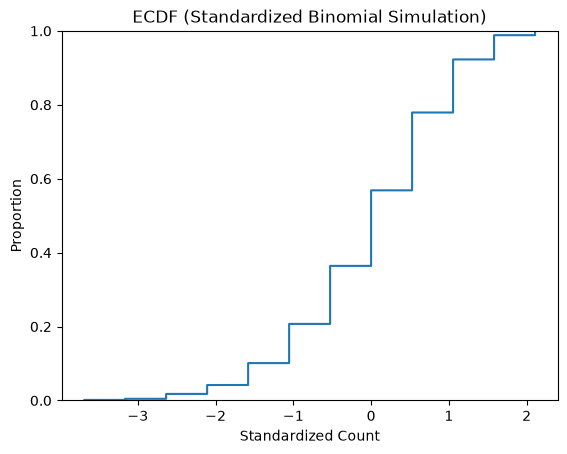

In [ ]:
n = 40
p = 0.9
b = 5000
results = []

for i in range(b):
    heads = np.random.binomial(n=n, p=p)
    z = (heads - n*p) / np.sqrt(n*p*(1-p))
    results.append(z)
results = np.array(results)
sns.ecdfplot(results)
plt.xlabel("Standardized Number of Survivors")
plt.ylabel("Proportion")
plt.title("ECDF of Survivors (Standardized)")
plt.show()

The closer our p-value is towards .5, the standardized count appears closer to a normal distribution. The closer our p-value is towards 0 or 1, the standardization count shows larger deviations away from a normal distribution curve.

### Question 4

A process is running in discrete time. In each time interval of length dt, it terminates with probability r * dt, where r * dt < 1. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

**1. For each simulation of the process, determine the period in which termination occurs.**

If our termination probability is r * dt, then our survival probability is 1 - r * dt. To determine the period in which termination occurs, we start at the simulation at period=0 and repeatedly check whether the process terminates during that period. If the process survives, the simulation moves to the next period and repeat the check, continuing until the termination occurs. The period number at which the first termination occurs is recorded as the result of the simulation.

In [27]:
r = 1
dt = 1e-3
n = 5000
times = []

period = 0
while True:
    period += 1
    if np.random.random() < r * dt:
        break

print(period)

 

1390


**2. Convert periods to time by multiplying by dt**

In [28]:
t_time = period * dt
times.append(t_time)

**3. Repeat the simulation n = 5000 times and plot the ECDF, for a value of dt close to zero (e.g. dt = 1e-3).**

In [29]:
for i in range(n):
    period = 0
    while True:
        period += 1
        if np.random.random() < r * dt:
            break
    times.append(period * dt)

In [30]:
times = np.array(times)

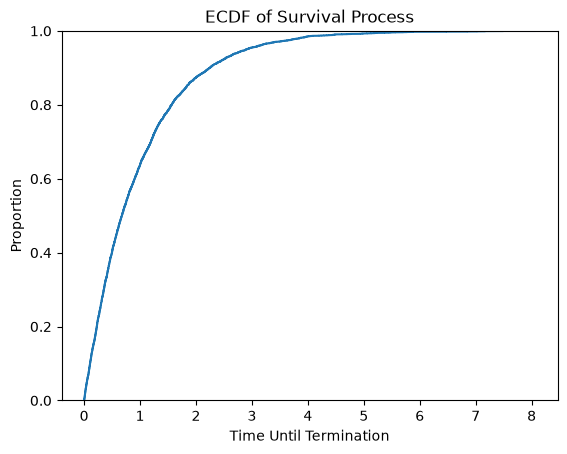

In [31]:
sns.ecdfplot(times)
plt.xlabel("Time Until Termination")
plt.ylabel("Proportion")
plt.title("ECDF of Survival Process")
plt.show()

**4. What distribution does this approach as dt goes to zero?**

In each interval of dt, the survival process terminates with probability r * dt, so termination can occur at any moment in continuous time. As the intervals become smaller and smaller, the waiting time until termination converges to an Exponential random variable. Therefore, the ECDF of the simulated termination should become increasingly similar to an exponential CDF: (F(t)= 1 − e^−rt).

**5. How do the results change as you adjust r?**

"r" controls the rate at which termination occurs. Therefore, increasing r increases the probability of termination during each time interval, causing the process to terminate more quickly on average. As a result, the distribution of termination times approach closer to zero, and the ECDF rises more steeply.

Decreasing our r reduces the probability of termination during each interval, causing the survival process to last longer and creating a larger waiting time before the termination. Therefore, the ECDF will spread more gradually and will spread further to the right of zero.

### Question 5

We're going to draw a sample of values, sort them, and track a particular rank. This is particularly useful for understanding extreme events: We might be interested in the behavior of the biggest storm or earthquake each year, but be working with a dataset about storms in general over 25 or 50 years.

**1. Draw  values K = 20 from Uniform[0, 1].**

In [36]:
K = 20
values = np.random.uniform(low=0, high=1, size=K)
print(values)

[0.05270854 0.77856831 0.59010289 0.46672008 0.99425767 0.3591758
 0.0127642  0.58073699 0.67837817 0.82509333 0.10926178 0.50131121
 0.10851302 0.65362296 0.03199814 0.39689706 0.46411538 0.7493605
 0.27115724 0.03831926]


**2. Sort them by size from smallest to largest.**

In [37]:
sorted_values = np.sort(values)
print(sorted_values)

[0.0127642  0.03199814 0.03831926 0.05270854 0.10851302 0.10926178
 0.27115724 0.3591758  0.39689706 0.46411538 0.46672008 0.50131121
 0.58073699 0.59010289 0.65362296 0.67837817 0.7493605  0.77856831
 0.82509333 0.99425767]


**3. Record the largest value**

In [38]:
largest_value = sorted_values[-1]
print(largest_value)

0.994257671266341


**4. Repeat n times and plot the ECDF.**

In [41]:
n = 5000
largest_values = []

for i in range(n):
    values = np.random.uniform(low=0, high=1, size=K)
    sorted_values = np.sort(values)
    largest_value = sorted_values[-1]
    largest_values.append(largest_value)

largest_values = np.array(largest_values)

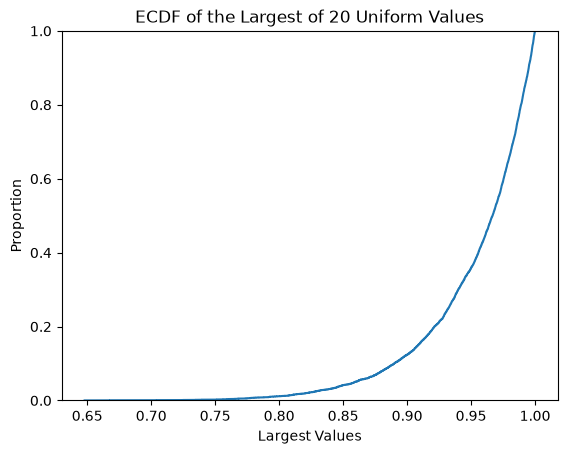

In [ ]:
sns.ecdfplot(x=largest_values)
plt.xlabel("Largest Values")
plt.ylabel("Proportion")
plt.title("ECDF of 20 Largest Values")
plt.show()

**5. Repeat the previous steps for each rank from 1 to K**

In [ ]:
ranked_values = np.empty((n, K))

In [47]:
for i in range(n):
    values = np.random.uniform(low=0, high=1, size=K)
    ranked_values[i, :] = np.sort(values)

In [51]:
rank_df = pd.DataFrame(
    ranked_values,
    columns=np.arange(1, K + 1)
)

rank_df_long = rank_df.melt(
    var_name="Rank",
    value_name="Value"
)

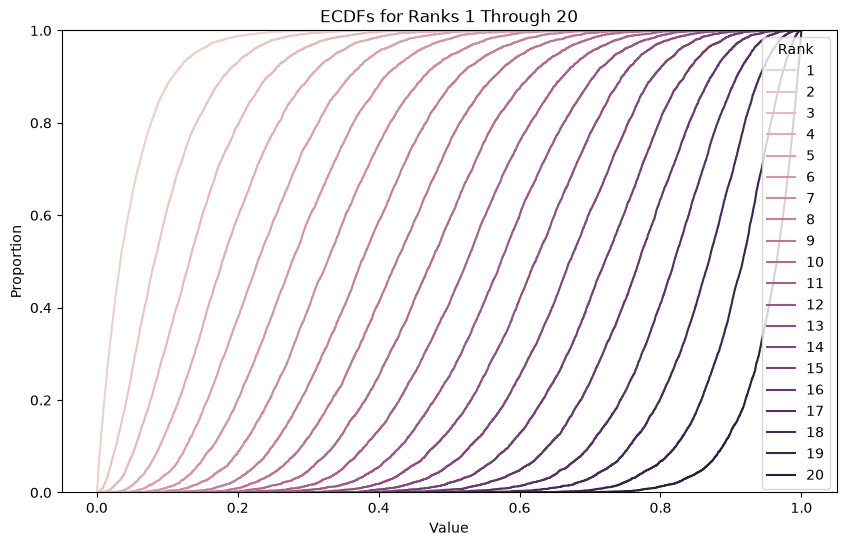

In [53]:
plt.figure(figsize=(10, 6))

sns.ecdfplot(
    data=rank_df_long,
    x="Value",
    hue="Rank",
)

plt.xlabel("Value")
plt.ylabel("Proportion")
plt.title("ECDFs for Ranks 1 Through 20")
plt.show()

**6. What distribution(s) does this process generate? How does the distribution depend on the rank?**

The uniform distribution spreads probability evenly over an intervalAs the rank becomes higher, the distributions shift to the right because our sorting made higher ranks represent larger values. Ranks closer to 1 are near 0, ranks in the middle are closer to the center, and ranks closer to 20 are near 1.

### Question 7

A surprising regularity appears again and again in human populations: the second-largest city is often roughly half the size of the largest, the third-largest roughly one-third the size, and so on. This relationship is called Zipf's law, and it connects the rank of an observation to its size.

**1. Suppose there are K = 100_000 cities, ranked from largest to smallest. Create the ranks *{1 , ... , K}*.**

In [54]:
K = 100_000
ranks = np.arange(1, K + 1)

**2. Zipf's law says that the size of the city with rank  is proportional to xr = (K/r)^2. Start with s=1.**

In [56]:
s = 1
sizes = (K / ranks) ** s

**3. Randomly sample n=5_000 ranks, with each rank equally likely, and record the corresponding sizes.**

In [57]:
n = 5_000
sample_ranks = np.random.choice(ranks, size=n, replace=True)
sample_sizes = (K / sample_ranks) ** s

In [58]:
sample_sizes

array([ 1.75060834,  1.36995685, 28.84338044, ...,  3.34873753,
        1.06079411,  1.17115218], shape=(5000,))

**4. Plot the ECDF of the simulated sizes.**

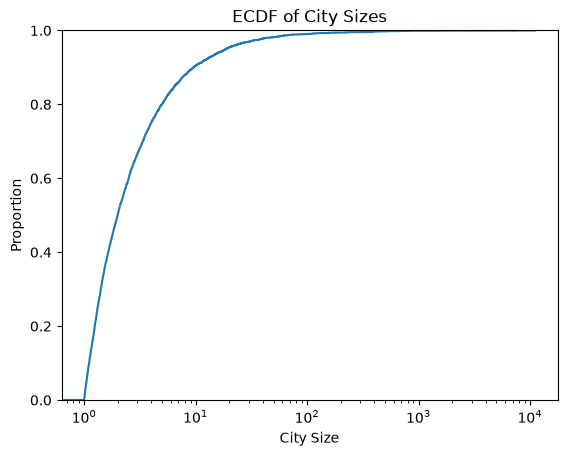

In [61]:
sns.ecdfplot(x=sample_sizes)
plt.xscale("log")
plt.xlabel("City Size")
plt.ylabel("Proportion")
plt.title("ECDF of City Sizes")
plt.show()

**5. What distribution does this generate as K becomes large?**

As K becomes "large", the distributions appear closer to a continuous Uniform variable. Therefore, the transformed size follows a Pareto distribution. For s=1, the minimum size is 1 and the Pareto shape parameter is 1. Most cities have relatively small sizes, but a small number of highly ranked cities have extremely large sizes, producing the long right tail.

**6. How does the distribution change as you adjust s?**

s controls  how rapidly the city size decreases as the rank increases. Increasing s makes low-ranked cities appear much larger relative to high-ranked cities, producing a more right-skewed distribution with a heavier tail and more extreme values. Decreasing s reduces the differences among city sizes, resulting in a less dispersed distribution. 